In [7]:
import os
import sys
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [21]:
def convert_rgb(rgb):
    # (r,g,b)
    hex_color = '#%02x%02x%02x' % rgb
    return hex_color

#### Consistency ranking

In [27]:
def matching_counts(df, pred_id=0):

    total_cnt = 0
    correct_cnt = 0; false_cnt = 0; partial_cnt = 0
    grouped = df.groupby(['gene1', 'gene2'])
    for (g1, g2), group in grouped:
        if len(group) > 1:
            total_cnt += 1
            predict_order = group.sort_values(by=f'predict_{pred_id}', ascending=False)['cancer'].tolist()
            true_order = group.sort_values(by='true', ascending=False)['cancer'].tolist()
            if len(set(df['cancer'])) == 2:
                if predict_order == true_order:
                    correct_cnt += 1
                else:
                    false_cnt += 1
            elif len(set(df['cancer'])) > 2:
                if predict_order == true_order:
                    correct_cnt += 1
                elif predict_order[::-1] == true_order:
                    false_cnt += 1
                else:
                    partial_cnt += 1
    return correct_cnt/total_cnt, partial_cnt/total_cnt, false_cnt/total_cnt

def plot_matching_counts(df1, df2, study_name, ymax=1):

    list1 = [];  list2 = []
    for pred_id in range(5):
        res1 = matching_counts(df1, pred_id=pred_id)
        res2 = matching_counts(df2, pred_id=pred_id)
        if res1[1] == 0:
            num_class = 2
            list1.append([res1[0],res1[2]]); list2.append([res2[0],res2[2]])
        else:
            num_class = 3
            list1.append(res1); list2.append(res2)

    arr1 = np.array(list1)
    arr2 = np.array(list2)

    # Compute mean and std
    mean1 = arr1.mean(axis=0)
    std1 = arr1.std(axis=0)
    mean2 = arr2.mean(axis=0)
    std2 = arr2.std(axis=0)

    # Plotting
    x = np.arange(len(mean1))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(7, 7))
    fig.set_dpi(300)
    bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, label='SLfomrer (Cancer-Specific)', capsize=5, color=convert_rgb((251,179,127)))
    bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, label='SLformer (Mixed-Cancer)', capsize=5, color=convert_rgb((247,119,106)))

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height+0.05),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=15)

    ax.set_ylabel('Rate (%)', fontsize=15)
    ax.set_title(study_name, fontsize=15)
    ax.set_xticks(x)
    if num_class == 2:
        classes = ["Correct","Incorrect"]
        ax.set_xticklabels([classes[i] for i in x], fontsize=15)
    elif num_class == 3:
        classes = ["Correct","Partially Correct","Incorrect"]
        ax.set_xticklabels([classes[i] for i in x], fontsize=15)
    ax.set_ylim(0, ymax)
    ax.legend(fontsize=15)

    plt.tight_layout()
    plt.show()


1. Parrish 2021 data

In [29]:
res_dir = "../experiment/independent_test_on_mix/raw"
experiment = "paralog_study1_score"
df_cancer_specific = pd.read_csv(os.path.join(res_dir, f"compare_res_transformer_{experiment}_cancer_specific.csv"))
df_mix = pd.read_csv(os.path.join(res_dir, f"compare_res_transformer_{experiment}_mix.csv"))
df_rdn = pd.read_csv(os.path.join(res_dir, f"compare_res_rdn_{experiment}_mix.csv"))
df_cancer_specific

,gene1,gene2,cancer,predict,true,predict_0,predict_1,predict_2,predict_3,predict_4
0,G3BP2,G3BP1,CESC,146.0,0.778159,146.0,75.0,16.0,141.0,35.0
1,PDS5B,PDS5A,CESC,85.0,0.340190,85.0,13.0,58.0,85.0,122.0
2,ARPP19,ENSA,CESC,119.0,0.640841,119.0,34.0,43.0,60.0,14.0
3,ACSL3,ACSL4,CESC,40.0,0.561660,40.0,45.0,149.0,162.0,204.0
4,HNRNPD,HNRNPAB,CESC,9.0,0.472859,9.0,10.0,12.0,21.0,5.0
...,...,...,...,...,...,...,...,...,...,...
626,SLC25A36,SLC25A33,LUAD,342.0,0.881960,342.0,150.0,231.0,188.0,338.0
627,USP13,USP5,LUAD,361.0,0.889715,361.0,219.0,76.0,173.0,200.0
628,BTBD10,KCTD20,LUAD,244.0,0.893591,244.0,292.0,340.0,61.0,115.0
629,ZFAND6,ZFAND5,LUAD,357.0,0.948195,357.0,206.0,336.0,397.0,234.0


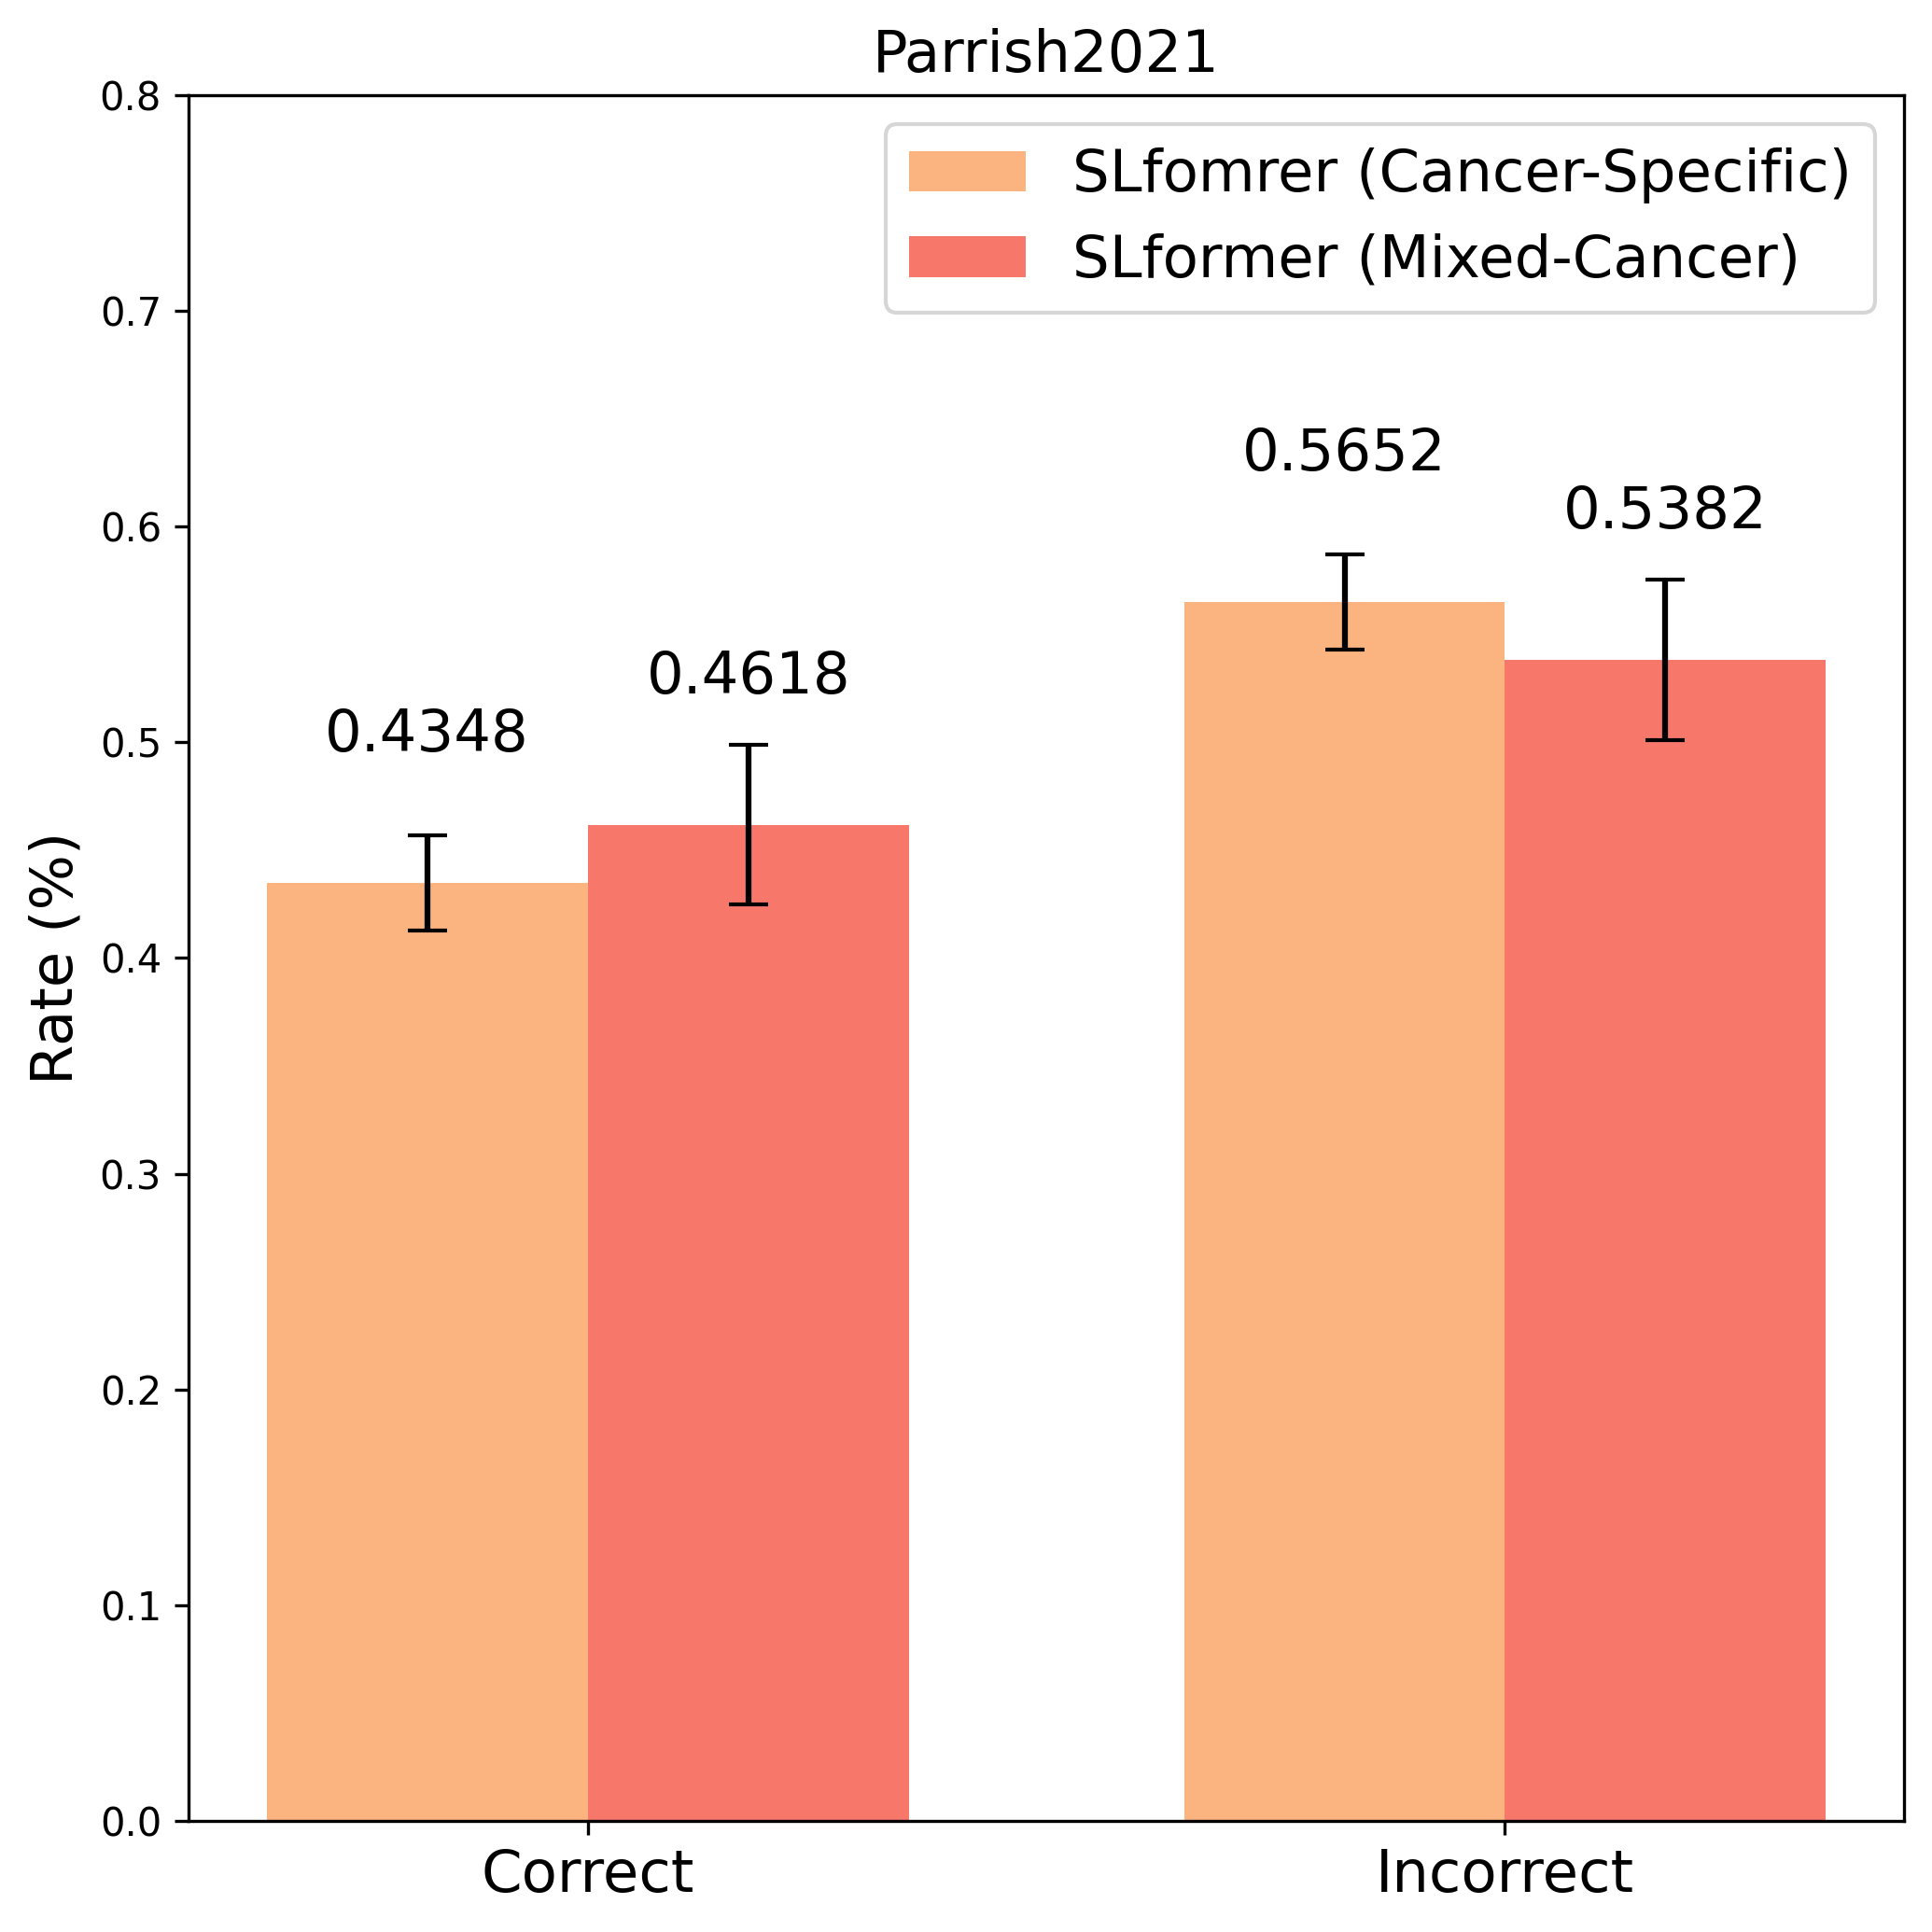

In [30]:
plot_matching_counts(df_cancer_specific, df_mix, study_name="Parrish2021", ymax=0.8)

2. Dede 2020 data

In [31]:
res_dir = "../experiment/independent_test_on_mix/raw"
experiment = "paralog_study2_score"
df_cancer_specific = pd.read_csv(os.path.join(res_dir, f"compare_res_transformer_{experiment}_cancer_specific.csv"))
df_mix = pd.read_csv(os.path.join(res_dir, f"compare_res_transformer_{experiment}_mix.csv"))
df_rdn = pd.read_csv(os.path.join(res_dir, f"compare_res_rdn_{experiment}_mix.csv"))
df_cancer_specific

,gene1,gene2,cancer,predict,true,predict_0,predict_1,predict_2,predict_3,predict_4
0,AP1B1,AP2B1,COAD,84.0,0.377654,84.0,152.0,89.0,125.0,92.0
1,ARFGEF1,ARFGEF2,COAD,70.0,0.420536,70.0,125.0,83.0,68.0,45.0
2,CAPZA1,CAPZA2,COAD,91.0,0.303476,91.0,52.0,59.0,124.0,86.0
3,CCNE1,CCNE2,COAD,22.0,0.485071,22.0,50.0,95.0,26.0,151.0
4,CHD1,CHD2,COAD,31.0,0.551890,31.0,9.0,21.0,69.0,4.0
...,...,...,...,...,...,...,...,...,...,...
543,ZNF26,ZNF268,OV,120.0,0.748900,120.0,155.0,127.0,79.0,110.0
544,ZNF524,ZNF581,OV,20.0,0.667181,20.0,25.0,23.0,33.0,10.0
545,ZNF580,ZNF581,OV,38.0,0.714947,38.0,89.0,41.0,68.0,22.0
546,ZSCAN21,ZSCAN30,OV,32.0,0.658538,32.0,106.0,9.0,36.0,27.0


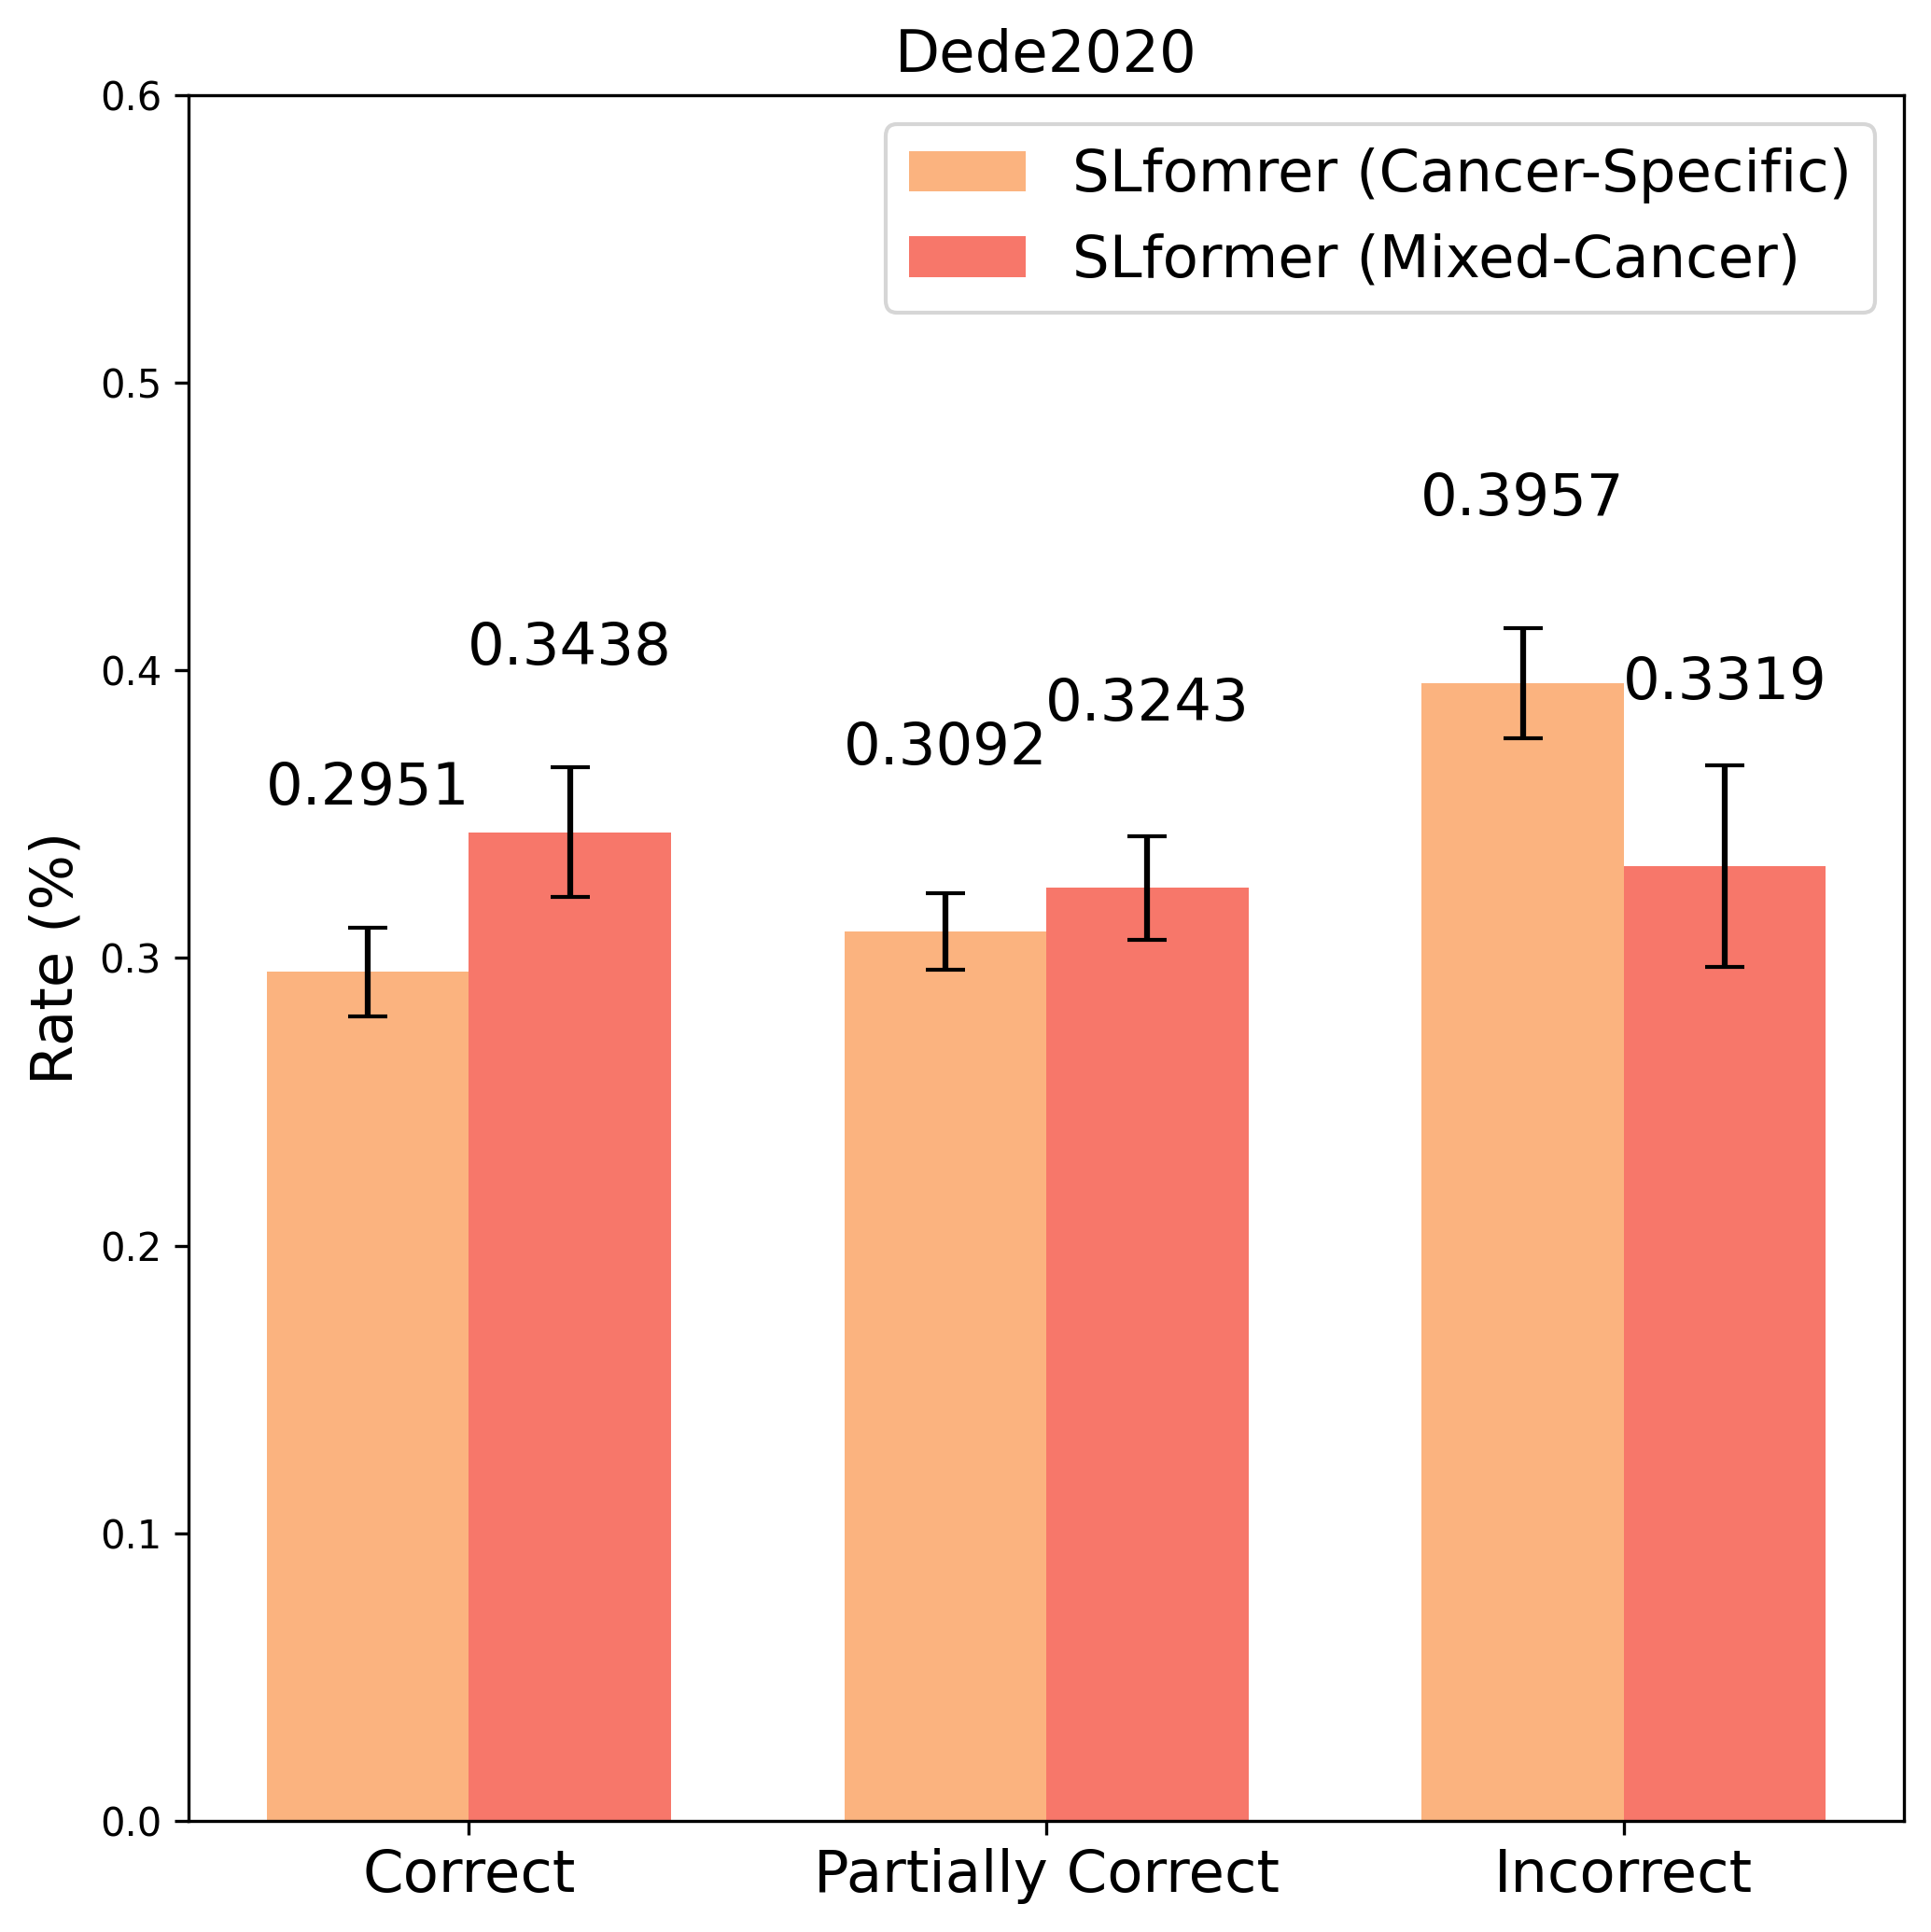

In [32]:
plot_matching_counts(df_cancer_specific, df_mix, study_name="Dede2020", ymax=0.6)